[ Amostra Biológica ] 
       ↓
[ 1. Sequenciador (NGS) ] → Gera arquivos FASTQ (Leituras brutas + Q-Score)
       ↓
[ 2. Bioinformática (BASH/Ferramentas Nativas) ]
       ├── Controle de Qualidade (Trimming de bases ruins)
       ├── Subtração do Hospedeiro (Remove DNA Humano usando genoma de referência)
       └── Alinhamento/Classificação (Compara a "sobra" com banco de patógenos)
       ↓
[ 3. Pipeline de Dados (Python / Pandas) ]
       ├── Filtragem de Nulos e Leitura Biológica (Trata NaN e limpa ruídos)
       ├── Sanitização de Sequências (Regex para validar A, T, C, G)
       ├── Controle de Qualidade Biológico (Valida Q-Score e Teor GC)
       └── Agrupamento e Métricas (groupby por Target_Patogeno)
       ↓
[ Relatório Diagnóstico / Laudo ]

Recebi uma planilha com dados brutos, pode ter vindo de exportações de maquina de NSG, PCR, planilhas preenchidas manualmente, sistemas LIMS ou banco de dados publicos (NCBI, Ensembl)
Preciso carregar esse arquivo bruto, e começar a limpeza no arquivo
Depois que o arquivo estiver limpo, vou salvar um novo arquivo, que poderá ser usado para analise final.

In [9]:
import pandas as pd
import numpy as np

# Simulando 50 registros de laboratório com vários tipos de ruído e erro
# Posso receber esse arquivo atraves de maquina de NGS, PCR, ou planilha manual, LIMS, NCBI, Ensembl
dados_sujos = {
    "ID_Amostra": [
        " am_001 ", "AM_002", "am_003", "AM_004", "am_005", "AM_006", "am_007", "AM_008", "am_009", "AM_010",
        "am_011", "AM_012", "am_013", "AM_014", "am_015", "AM_016", "am_017", "AM_018", "am_019", "AM_020",
        "am_021", "AM_022", "am_023", "AM_024", "am_025", "AM_026", "am_027", "AM_028", "am_029", "AM_030",
        "am_031", "AM_032", "am_033", "AM_034", "am_035", "AM_036", "am_037", "AM_038", "am_039", "AM_040",
        "AM_002", "am_005", "AM_012", # Duplicatas intencionais
        "am_041", "AM_042", "am_043", "AM_044", "am_045", "AM_046", "am_047"
    ],
    "Target_Patogeno": [
        "COVID-19", "covid-19", " Dengue ", "DENGUE", "Influenza_A", "influenza_a", None, "COVID-19", "Dengue", "HIV",
        "HIV", "covid-19", "Dengue", "Influenza_A", None, "COVID-19", "Dengue", "HIV", "Influenza_A", "COVID-19",
        "covid-19", "Dengue", "Influenza_A", "HIV", "COVID-19", "Dengue", "HIV", "Influenza_A", "COVID-19", "Dengue",
        "covid-19", "Dengue", "Influenza_A", "HIV", "COVID-19", "Dengue", "HIV", "Influenza_A", "COVID-19", "Dengue",
        "covid-19", "influenza_a", "covid-19", # Duplicatas
        "HIV", "COVID-19", "Dengue", "Influenza_A", "COVID-19", "Dengue", "HIV"
    ],
    "Sequencia_DNA": [
        "ATGCGGCGCCGTTTGA", "ATGCATGCATGCATGC", "GCGCGCGCGCGCGCGC", "AATTTAATTTAATTTA", "ATGCGGCXCGTTTGA",
        "ATGCATGC123ATGC", "GCGCGCGCGCGCGCGC", "NNNNNNNNNNNNNNNN", "ATGCGGCGCCGTTTGA", "ATGCATGCATGCATGC",
        "GCGCGCGCGCGCGCGC", "AATTTAATTTAATTTA", "ATGCGGCGCCGTTTGA", "ATGCATGCATGCATGC", "GCGCGCGCGCGCGCGC",
        "AATTTAATTTAATTTA", "ATGCGGCGCCGTTTGA", "ATGCATGCATGCATGC", "GCGCGCGCGCGCGCGC", "AATTTAATTTAATTTA",
        "ATGCGGCGCCGTTTGA", "ATGCATGCATGCATGC", "GCGCGCGCGCGCGCGC", "AATTTAATTTAATTTA", "ATGCGGCGCCGTTTGA",
        "ATGCATGCATGCATGC", "GCGCGCGCGCGCGCGC", "AATTTAATTTAATTTA", "ATGCGGCGCCGTTTGA", "ATGCATGCATGCATGC",
        "GCGCGCGCGCGCGCGC", "AATTTAATTTAATTTA", "ATGCGGCGCCGTTTGA", "ATGCATGCATGCATGC", "GCGCGCGCGCGCGCGC",
        "AATTTAATTTAATTTA", "ATGCGGCGCCGTTTGA", "ATGCATGCATGCATGC", "GCGCGCGCGCGCGCGC", "AATTTAATTTAATTTA",
        "ATGCATGCATGCATGC", "ATGCGGCXCGTTTGA", "AATTTAATTTAATTTA", # Duplicatas
        "ATGCGGCGCCGTTTGA", "ATGCATGCATGCATGC", "GCGCGCGCGCGCGCGC", "AATTTAATTTAATTTA", "ATGCGGCGCCGTTTGA",
        "ATGCATGCATGCATGC", "GCGCGCGCGCGCGCGC"
    ],
    "Teor_GC_%": [
        62.5, 50.0, 100.0, 0.0, 55.0, np.nan, 100.0, 0.0, 62.5, 50.0,
        150.0, 0.0, 62.5, 50.0, np.nan, 0.0, 62.5, -10.0, 100.0, 0.0,
        50.0, 50.0, 100.0, 0.0, 62.5, 50.0, 100.0, 0.0, 62.5, 50.0,
        50.0, 50.0, 100.0, 0.0, 62.5, 50.0, 100.0, 0.0, 62.5, 50.0,
        50.0, 55.0, 0.0, # Duplicatas
        62.5, 50.0, 100.0, 0.0, 62.5, 50.0, 100.0
    ],
    "Q_Score": [
        35, 30, 28, 12, np.nan, 22, 38, 5, 34, 31,
        29, 33, 36, 15, 32, 10, 39, 27, 33, 30,
        31, 29, 37, 14, 35, 30, 38, 11, 33, 28,
        30, 31, 36, 13, 34, 29, 37, 12, 32, 30,
        30, np.nan, 33, # Duplicatas
        35, 30, 38, 10, 34, 31, 36
    ]
}

df_bruto = pd.DataFrame(dados_sujos)
df_bruto.to_csv("dados_laboratorio_sujo.csv", index=False)
print("Arquivo 'dados_laboratorio_sujo.csv' gerado com sucesso!")

Arquivo 'dados_laboratorio_sujo.csv' gerado com sucesso!


In [10]:
import pandas as pd
import numpy as np

# CARREGAR OS DADOS BRUTOS
df_bruto = pd.read_csv("dados_laboratorio_sujo.csv")
print(f"Total de linhas originais: {len(df_bruto)}")

# LIMPEZA DE DADOS: ver o que precisar ser limpo e depois limpar

# 1. VER AS INFORMAÇÕES
print(20*"=", "VISÃO GERAL", 20*"=")
df_bruto.info()

# 2. VER LINHAS VAZIAS
print(20*"=", "CONTAGEM DE NULOS", 20*"=")
print(df_bruto.isna().sum())

print(20*"=", "EXIBINDO LINHAS COM VAZIOS", 20*"=")
print(df_bruto[df_bruto.isna().any(axis=1)])


Total de linhas originais: 50
==================== VISÃO GERAL ====================
<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID_Amostra       50 non-null     str    
 1   Target_Patogeno  48 non-null     str    
 2   Sequencia_DNA    50 non-null     str    
 3   Teor_GC_%        48 non-null     float64
 4   Q_Score          48 non-null     float64
dtypes: float64(2), str(3)
memory usage: 3.5 KB
==================== CONTAGEM DE NULOS ====================
ID_Amostra         0
Target_Patogeno    2
Sequencia_DNA      0
Teor_GC_%          2
Q_Score            2
dtype: int64
==================== EXIBINDO LINHAS COM VAZIOS ====================
   ID_Amostra Target_Patogeno     Sequencia_DNA  Teor_GC_%  Q_Score
4      am_005     Influenza_A   ATGCGGCXCGTTTGA       55.0      NaN
5      AM_006     influenza_a   ATGCATGC123ATGC        NaN     22.0
6   

In [21]:
# 3. LIMPAR ESSAS LINHAS VAZIAS
# Remove linhas onde o patógeno está ausente
df = df_bruto.dropna(subset=["Target_Patogeno"])

# Preenche vazios numéricos: poderia do Q_Score com a mediana
    # Não é o correto biologicamente falando, mas para fins didáticos é importante saber dessa opção.
    # mediana_q = df["Q_Score"].median()

# coloca a mediana em todas as linhas Nan da coluna Q_Score. No mundo real, deletar essas linhas/ refazer análise
    # df["Q_Score"] = df["Q_Score"].fillna(mediana_q) 

# 4. PADRONIZAÇÃO (Tudo maiúsculo, sem espaços extras)
df["ID_Amostra"] = df["ID_Amostra"].astype(str).str.strip().str.upper()
df["Target_Patogeno"] = df["Target_Patogeno"].astype(str).str.strip().str.upper()

# 5. REMOVER DUPLICATAS E FINALIZAR
linhas_duplicadas = df[df.duplicated(keep=False)]
print("="*20, "LINHAS 100% REPETIDAS NA PLANILHA", 20*"=")
print(linhas_duplicadas)
print(f"\nTotal de linhas totalmente duplicadas: {df.duplicated().sum()}")
df = df.drop_duplicates(subset=["ID_Amostra"]) 
    # parametro subset diz qual coluna especifica eu quero remover as duplicatas
    # normalmente o paciente tem um id_paciente unico e pode ter diferentes id_amostra. 
    # Posso ver se há duplicatas de id_amostra para ver se nao foi inserida duas vezes.
print("="*20, "LINHAS SEM DUPLICAÇÃO", 20*"=")
print(df)

# 6. Identifiquei "Nan" na coluna "Teor_gc", valores negativos e sequencia de dna errada
df = df.dropna(subset=["Teor_GC_%"])
invalido_gc = df[(df["Teor_GC_%"] < 0) | (df["Teor_GC_%"] > 100)]
print(20*"=","VALORES DE GC INVALIDOS", 20*"=")
print(invalido_gc)

# Mantém apenas valores biologicamente válidos (entre 0% e 100%)
df = df[(df["Teor_GC_%"] >= 0) & (df["Teor_GC_%"] <= 100)]


# Filtrar apenas sequencias de DNA válidas: apenas (A, T, C, G) e apenas letras, sem numeros
import re

padrao_dna_valido = r"^[ATCG]+$"
# r'^[ATCG]+$'
    # ^ indica o inicio da string
    # [A, T, C, G] define apenas os caracteres que sao permitidos
    # + exige que haja pelo menos um desses caracteres => IMPORTANTE NÃO COLOCAR ESPAÇO antes e depois do "+" se não vai excluir tudo
    # $ indidca o fim da string
df = df[df["Sequencia_DNA"].str.match(padrao_dna_valido, na=False)]

print(20*"=","DATAFRAME LIMPO COM SUCESSO",20*"=")
print(df) 

==================== LINHAS 100% REPETIDAS NA PLANILHA ====================
   ID_Amostra Target_Patogeno     Sequencia_DNA  Teor_GC_%  Q_Score
1      AM_002        COVID-19  ATGCATGCATGCATGC       50.0     30.0
4      AM_005     INFLUENZA_A   ATGCGGCXCGTTTGA       55.0      NaN
11     AM_012        COVID-19  AATTTAATTTAATTTA        0.0     33.0
40     AM_002        COVID-19  ATGCATGCATGCATGC       50.0     30.0
41     AM_005     INFLUENZA_A   ATGCGGCXCGTTTGA       55.0      NaN
42     AM_012        COVID-19  AATTTAATTTAATTTA        0.0     33.0

Total de linhas totalmente duplicadas: 3
==================== LINHAS SEM DUPLICAÇÃO ====================
   ID_Amostra Target_Patogeno     Sequencia_DNA  Teor_GC_%  Q_Score
0      AM_001        COVID-19  ATGCGGCGCCGTTTGA       62.5     35.0
1      AM_002        COVID-19  ATGCATGCATGCATGC       50.0     30.0
2      AM_003          DENGUE  GCGCGCGCGCGCGCGC      100.0     28.0
3      AM_004          DENGUE  AATTTAATTTAATTTA        0.0     12.0
4 

In [12]:
# 7. AGRUPAMENTO E JUNÇÃO PARA POSSÍVEIS PERGUNTAS

#Contar quantas amostras existem para cada patógeno
# groupby("coluna que define os grupos") seguido de uma operação(size(), mean(), sum(), count()) que dizer o que fazer dentro de cada grpo
contagem_patogenos = df.groupby("Target_Patogeno")["ID_Amostra"].count() #conta quantas id_amostra tem em cada "target_patogeno"
print(20*"=", "AMOSTRAS POR PATÓGENO", 20*"=")
print(contagem_patogenos)

# MÉDIA DAS MÉTRICAS POR GRUPO
resumo_metricas = df.groupby("Target_Patogeno")[["Q_Score", "Teor_GC_%"]].mean() # vou agrupar por setor, mas ao invez de contar, pega a media de cada setor
print(20*"=", "MÉDIA DAS MÉTRICAS POR GRUPO", 20*"=")
print(resumo_metricas)

==================== AMOSTRAS POR PATÓGENO ====================
Target_Patogeno
COVID-19       13
DENGUE         13
HIV             7
INFLUENZA_A     7
Name: ID_Amostra, dtype: int64
==================== MÉDIA DAS MÉTRICAS POR GRUPO ====================
                   Q_Score  Teor_GC_%
Target_Patogeno                      
COVID-19         30.538462  44.230769
DENGUE           30.384615  56.730769
HIV              29.142857  58.928571
INFLUENZA_A      22.000000  50.000000


# PQ OS CÁLCULOS?

Q_SCORE: Servepara saber, de forma geral, se a qualidade do sequenciamento daquele grupo(por patogeno) está boa ou ruim. Uma média baixa é um sinal de alerta => essas amostras podem estar precisando ser resenquenciadas. Indica qualidade do **PROCESSO**

TEOR_GC: é uma caracteristica do proprio patogeno. Cada organismo tem uma faixa de gc esperada. Se a média do grupo "COVID" no dados estiver muito fora do esperado pra esse vírus, pode indicar contaminação do patógeno.

In [13]:
# CRIAR RELATÓRIO COMPLETO
# agg() fazer mais de uma conta ao mesmo tempo
relatorio = df.groupby("Target_Patogeno").agg(
    total_amostras = ("ID_Amostra", "count"), # "coluna original", "conta a fazer"
    q_score_media = ("Q_Score", "mean"),
    q_score_minimo = ("Q_Score", "min"),
    gc_medio = ("Teor_GC_%", "mean")
)
print(relatorio)

                 total_amostras  q_score_media  q_score_minimo   gc_medio
Target_Patogeno                                                          
COVID-19                     13      30.538462            10.0  44.230769
DENGUE                       13      30.384615            12.0  56.730769
HIV                           7      29.142857            13.0  58.928571
INFLUENZA_A                   7      22.000000            10.0  50.000000


Na rotina real de diagnósticos, o resultado do sequenciamento/PCR precisa ser cruzado com as informações dos pacientes (como idade, tipo de amostra ou data de coleta).

In [14]:
# Criando tabela de metadados dos pacientes/ amostras

import pandas as pd
import numpy as np

# Tabela 2: Metadados dos Pacientes/Amostras
#p=[] diz a chance de cada opção, tipo 40% de chance de ser swab, 30% de ser sangue
# np.random.choice() => escolhe uma opção que eu ja defini em uma listaa
# np.random.randint() => sortear um numero inteiro dentro de um intervalo => só digo o minimo e o máximo, não dou uma lista
    # pode sair qualquer numero entre 1 e 84
dados_pacientes = {
    "ID_Amostra" : [f"AM_{i:03d}" for i in range(1,51)],
    "Tipo_Amostra" : np.random.choice(
        ["Swab Nasofaringeo", "Sangue Total", "Saliva", "Lavado Broncoalveolar"], size=50, p=[0.4, 0.3, 0.2, 0.1]  
    ),
    "Idade_Paciente" : np.random.randint(1, 85, size = 50),
    "Sexo" : np.random.choice(["M", "F"], size = 50), # sem p=[], portanto é 50/50
    "Setor_Hospitalar" : np.random.choice(
        ["UTI", "PS", "Internação", "Ambulatório", "Pediatria"], size=50),
    "Região_Coleta" : np.random.choice(["Sudeste", "Sul", "Nordeste", "Norte", "Centro-Oeste"], size=50),
    "Status_Vacinal" : np.random.choice(["Completo", "Incompleto", "Não informado"], size=50, p=[0.7, 0.2, 0.1])
    }
df_pacientes = pd.DataFrame(dados_pacientes) #transforme esses dados em uma tabela de verdade (DataFrame)

# configuração visual para exibir TODAS as colunas sem cortar no terminal

pd.set_option("display.max_columns", None)
# manda o Pandas mostrar todas as colunas da tabela, sem cortar nenhuma(None significa sem limite)
# display.max_columns normalmente espera um número — por exemplo, 10 diria "mostra no máximo 10 colunas".
# Sem essa linha, se a tabela tiver muitas colunas, o Pandas esconde algumas no meio e mostra só um "..." no lugar.
pd.set_option("display.width", 1000)
# define a largura máxima (em caracteres) que o Pandas usa pra imprimir a tabela numa linha só. 
# Sem isso, se a tabela for larga, o Pandas quebra ela em várias linhas, ficando bagunçado de ler.

print(f"Total de metadados cadastrados: {len(df_pacientes)} amostras")
print(df_pacientes.head(10)) # Mostra as 10 primeiras para conferir


Total de metadados cadastrados: 50 amostras
  ID_Amostra           Tipo_Amostra  Idade_Paciente Sexo Setor_Hospitalar Região_Coleta Status_Vacinal
0     AM_001           Sangue Total              75    F               PS       Sudeste       Completo
1     AM_002  Lavado Broncoalveolar              55    M       Internação       Sudeste       Completo
2     AM_003      Swab Nasofaringeo              36    F       Internação  Centro-Oeste  Não informado
3     AM_004           Sangue Total              14    F        Pediatria           Sul       Completo
4     AM_005      Swab Nasofaringeo              29    F       Internação      Nordeste       Completo
5     AM_006                 Saliva              65    M       Internação       Sudeste     Incompleto
6     AM_007      Swab Nasofaringeo              60    M               PS       Sudeste       Completo
7     AM_008      Swab Nasofaringeo              60    M               PS  Centro-Oeste       Completo
8     AM_009      Swab Nasofa

In [ ]:
# Cruzamento mantendo todas as amostras limpas do seu pipeline
df_completo = pd.merge(df, df_pacientes, on="ID_Amostra", how="left")
# Aqui é o ponto mais importante: junta sua tabela de sequenciamento (df) com essa nova tabela de pacientes (df_pacientes), 
# usando ID_Amostra como chave — como se fosse um PROCV do Excel, ou seja, a "coluna em comum"
# how="left" significa: how="left" quer dizer: mantém todas as linhas da tabela da esquerda (df), não importa se ela tem par na direita ou não. 
    # Se uma amostra existir em df mas não existir em df_pacientes, ela não é descartada — só fica com os dados de paciente vazios (NaN).

df_completo

,ID_Amostra,Target_Patogeno,Sequencia_DNA,Teor_GC_%,Q_Score,Tipo_Amostra,Idade_Paciente,Sexo,Setor_Hospitalar,Região_Coleta,Status_Vacinal
0,AM_001,COVID-19,ATGCGGCGCCGTTTGA,62.5,35.0,Sangue Total,75,F,PS,Sudeste,Completo
1,AM_002,COVID-19,ATGCATGCATGCATGC,50.0,30.0,Lavado Broncoalveolar,55,M,Internação,Sudeste,Completo
2,AM_003,DENGUE,GCGCGCGCGCGCGCGC,100.0,28.0,Swab Nasofaringeo,36,F,Internação,Centro-Oeste,Não informado
3,AM_004,DENGUE,AATTTAATTTAATTTA,0.0,12.0,Sangue Total,14,F,Pediatria,Sul,Completo
4,AM_009,DENGUE,ATGCGGCGCCGTTTGA,62.5,34.0,Swab Nasofaringeo,47,F,UTI,Sudeste,Completo
5,AM_010,HIV,ATGCATGCATGCATGC,50.0,31.0,Swab Nasofaringeo,3,F,Internação,Nordeste,Completo
6,AM_012,COVID-19,AATTTAATTTAATTTA,0.0,33.0,Sangue Total,39,M,Internação,Norte,Completo
7,AM_013,DENGUE,ATGCGGCGCCGTTTGA,62.5,36.0,Swab Nasofaringeo,13,F,Ambulatório,Sudeste,Completo
8,AM_014,INFLUENZA_A,ATGCATGCATGCATGC,50.0,15.0,Sangue Total,54,F,UTI,Centro-Oeste,Completo
9,AM_016,COVID-19,AATTTAATTTAATTTA,0.0,10.0,Lavado Broncoalveolar,62,M,PS,Nordeste,Incompleto


Mostrar os resultados em gráficos

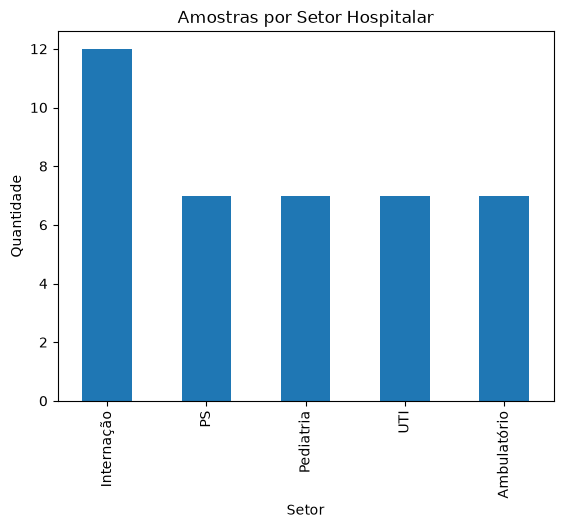

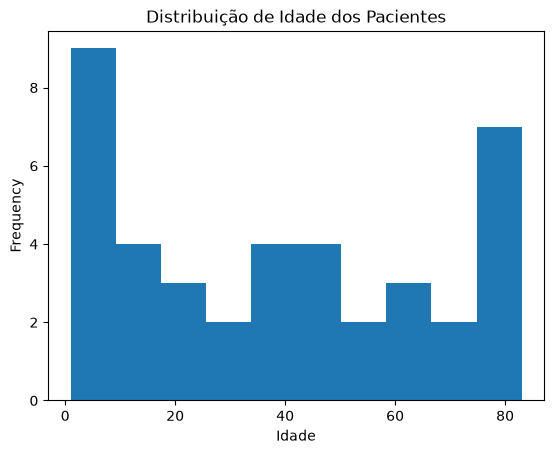

Text(0.5, 1.0, 'Q_Score médio por Setor Hospitalar')

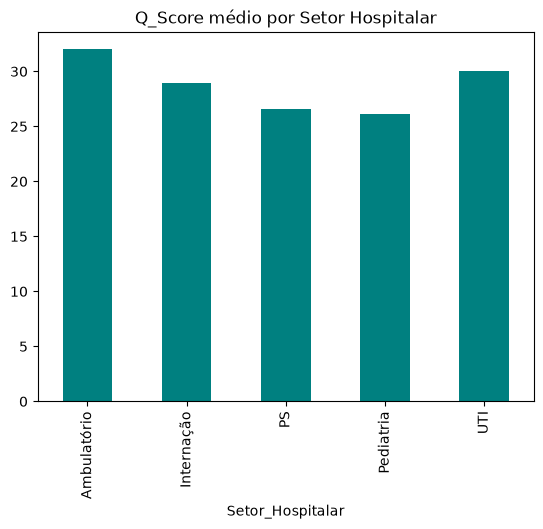

In [26]:
import matplotlib.pyplot as plt # precisa instalar

# Contagem de amostras por setor hospitalar 
df_completo["Setor_Hospitalar"].value_counts().plot(kind="bar")
plt.title("Amostras por Setor Hospitalar")
plt.xlabel("Setor")
plt.ylabel("Quantidade")
plt.show()

# Distribuição de idade dos pacientes

df_completo["Idade_Paciente"].plot(kind="hist", bins=10) # hitograma e divide as idades em 10 faixas
plt.title("Distribuição de Idade dos Pacientes")
plt.xlabel("Idade")
plt.show()

# Matplotlib mais avançado usando o groupby()
df_completo.groupby("Setor_Hospitalar")["Q_Score"].mean().plot(kind="bar", color="teal")
plt.title("Q_Score médio por Setor Hospitalar")


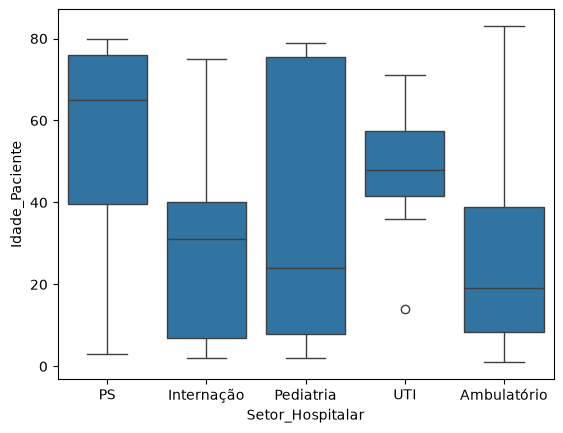

In [ ]:
import seaborn as sns
sns.boxplot(data=df_completo, x="Setor_Hospitalar", y="Idade_Paciente")
plt.show()
# Isso mostra a distribuição de idade dentro de cada setor, não só uma média

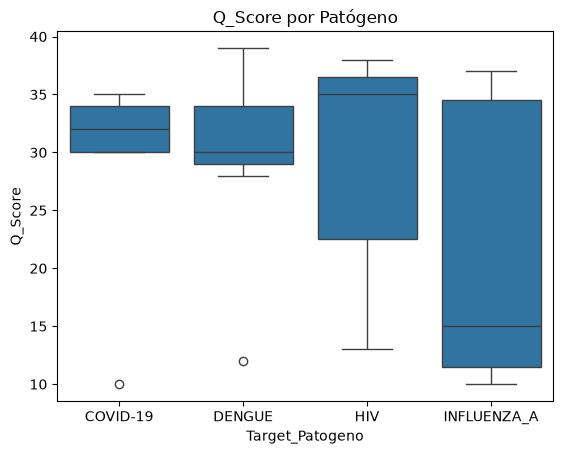

In [ ]:
# Boxplot: Q_Score por patógeno
# Você quer ver se a qualidade da leitura (Q_Score) varia entre os patógenos, incluindo os casos fora do padrão — não só a média.

sns.boxplot(data=df_completo, x="Target_Patogeno", y="Q_Score")
plt.title("Q_Score por Patógeno")
plt.show()

# a linha do meio de cada caixa é a mediana. A caixa mostra onde está a maioria dos valores.
# Pontinhos fora da caixa são os "outliers" = valores muito diferentes do resto.

É possível observar que HIV e Influenza_a tem caixas maiores, ou seja, a qualidade das leituras variam. Tem amostra boa e ruim misturada.
Já COVID e DENGUE tem caixas mais achatadas e altas, indicando leitura mais consistente e de qualidade melhor
Influenza tem a mediana mais baixa de todas, pior qualidade.
COVID e DENGUE tem circulos sozinhos, são outliers, vale investigação nelas.

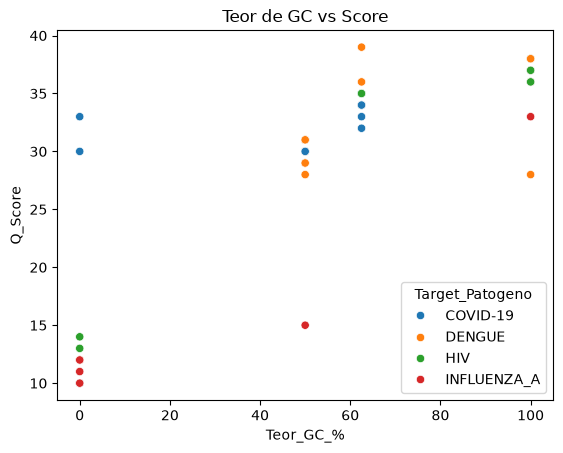

In [28]:
# Scatterplot: Teor de GC vs Q_Score
# Você quer ver se existe alguma relação entre o teor de GC da amostra e a qualidade da leitura.

sns.scatterplot(data=df_completo, x="Teor_GC_%", y="Q_Score", hue="Target_Patogeno")
plt.title("Teor de GC vs Score")
plt.show()

# Aqui, hue="Target_Patogeno" colore cada ponto de acordo com o patógeno — assim você vê se algum patógeno específico se agrupa num canto do gráfico.

Os pontos aparecem quase só em 3 posições de GC(perto de 0,50 e 100), o que é estranho biologicamente falando. Teor de GC costuma variar de forma mais constínua. Pode ser um sinal de que os testes nao representam GC real.
Nos pontos que estão em GC perto de 100, a maioria tem Q_Score alto (30-40) → nesse recorte específico, parece haver uma tendência de GC alto vindo com boa qualidade, mas com poucos pontos não dá pra confirmar isso com confiança
As cores não formam grupos separados — COVID-19, DENGUE, HIV aparecem espalhados nas mesmas faixas de GC → isso sugere que, nesse conjunto de dados, o teor de GC não é uma característica exclusiva de nenhum patógeno específico (o que também pode ser porque os dados foram gerados aleatoriamente, não são valores biológicos reais)